<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/fashionMNISTCNN/blob/main/FashionMNISTCNN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

In [ ]:
train_data=datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None)

test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [ ]:
len(train_data),len(test_data)

(60000, 10000)

In [ ]:
image,label=train_data[0]
class_name=train_data.classes
class_to_idx=train_data.class_to_idx

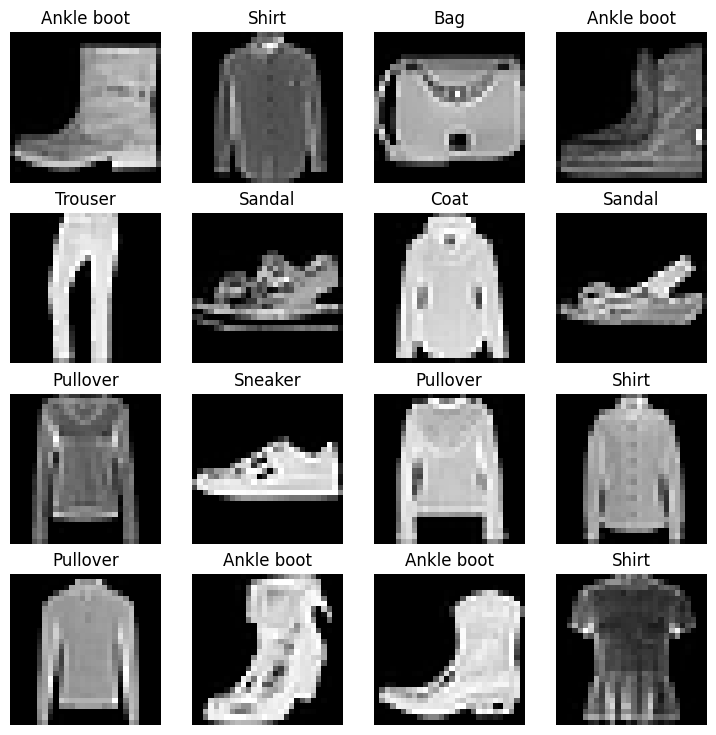

In [ ]:
torch.manual_seed(42)
fig=plt.figure(figsize=(9,9))
rows,cols=4,4
for i in range(1,rows*cols+1):
  random_idx=torch.randint(0,len(train_data),size=[1]).item()
  image,label=train_data[random_idx]
  fig.add_subplot(rows,cols,i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_name[label])
  plt.axis(False)

In [ ]:
from torch.utils.data import DataLoader
BATCH_SIZE=32

train_dataloader=DataLoader(dataset=train_data,batch_size=BATCH_SIZE,shuffle=True)
test_dataloader=DataLoader(dataset=test_data,batch_size=BATCH_SIZE,shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7fbfde7f2900>,
 <torch.utils.data.dataloader.DataLoader at 0x7fbfdeb6b770>)

In [ ]:
train_features_batch,train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [ ]:
def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

In [ ]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, device: torch.device = None):
  total_time = end - start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

In [ ]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [ ]:
torch.cuda.is_available()

False

In [ ]:
import torch
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [ ]:
def train_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               optimizer:torch.optim.Optimizer,
               accuracy_fn,
               device:torch.device):
  train_loss,train_acc=0,0
  for batch,(x,y) in enumerate(data_loader):
    model.train()
    x,y=x.to(device),y.to(device)
    y_pred=model(x)
    loss=loss_fn(y_pred,y)
    train_loss+=loss
    train_acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss/=len(data_loader)
  train_acc/=len(data_loader)
  print(f"train loss:{train_loss:.5f}, train acc:{train_acc:2f}%")

In [ ]:
def test_step(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
              loss_fn:torch.nn.Module,
              accuracy_fn,
              device:torch.device):
  test_loss,test_acc=0,0
  model.eval()

  with torch.inference_mode():
    for x,y in data_loader:
      x,y=x.to(device),y.to(device)
      test_pred=model(x)
      test_loss+=loss_fn(test_pred,y)
      test_acc+=accuracy_fn(y_true=y,y_pred=test_pred.argmax(dim=1))

    test_loss/=len(data_loader)
    test_acc/=len(data_loader)
    print(f"test loss:{test_loss:.5f}, test acc:{test_acc:2f}%")

In [ ]:
def eval_model(model:torch.nn.Module,data_loader:torch.utils.data.DataLoader,loss_fn:torch.nn.Module,accuracy_fn,device=device):
  loss,acc=0,0
  model.eval()
  with torch.inference_mode():
    for x,y in tqdm(data_loader):
      x,y=x.to(device),y.to(device)
      y_pred=model(x)
      loss+=loss_fn(y_pred,y)
      acc+=accuracy_fn(y_true=y,y_pred=y_pred.argmax(dim=1))


    loss /= len(data_loader)
    acc /= len(data_loader)


  return {"model_name":model.__class__.__name__,
          "model_loss":loss.item(),
          "model_acc":acc}

In [ ]:

class FashionMNISTModel02(nn.Module):
  def __init__(self,input_shape:int,hidden_units:int,output_shape:int):
    super().__init__()
    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),

       nn.ReLU(),
       nn.MaxPool2d(kernel_size=2)

    )
    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape)
    )

  def forward(self,x:torch.Tensor):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    return x

In [ ]:
image.shape

torch.Size([1, 28, 28])

In [ ]:
torch.manual_seed(42)
model_2=FashionMNISTModel02(input_shape=1,
                            hidden_units=10,
                            output_shape=len(class_name)).to(device)

In [ ]:

loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_2.parameters(),lr=0.1)

In [ ]:
from tqdm.auto import tqdm


torch.manual_seed(42)
torch.cuda.manual_seed(42)


from timeit import default_timer as timer
train_time_start_model_2=timer()

epochs=3

for epoch in tqdm(range(epochs)):
  print(f"epoch:{epoch}")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2=timer()
total_train_time_model_2=print_train_time(start=train_time_start_model_2,
                                          end=train_time_end_model_2,
                                          device="cuda")

  0%|          | 0/3 [00:00<?, ?it/s]

epoch:0
train loss:0.63397, train acc:77.393333%
test loss:0.39545, test acc:85.772764%
epoch:1
train loss:0.36957, train acc:86.708333%
test loss:0.36046, test acc:87.220447%
epoch:2
train loss:0.33449, train acc:87.800000%
test loss:0.33884, test acc:87.919329%
Train time on cuda: 162.215 seconds


In [ ]:
model_2_results=eval_model(model=model_2,
                           data_loader=test_dataloader,
                           loss_fn=loss_fn,
                           accuracy_fn=accuracy_fn,
                           device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModel02',
 'model_loss': 0.33884355425834656,
 'model_acc': 87.91932907348243}

In [ ]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device:torch.device):
  pred_probs=[]
  model.eval()
  with torch.inference_mode():
    for sample in data:

      sample=torch.unsqueeze(sample,dim=0).to(device)
      pred_logit=model(sample)
      pred_prob=torch.softmax(pred_logit.squeeze(),dim=0)
      pred_probs.append(pred_prob.cpu())


  return torch.stack(pred_probs)

In [ ]:
import random
random.seed(42)
test_samples=[]
test_labels=[]
for sample,label in random.sample(list(test_data),k=9):
  test_samples.append(sample)
  test_labels.append(label)

test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

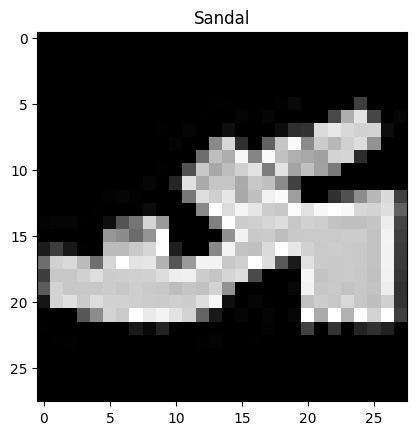

In [ ]:
plt.imshow(test_samples[0].squeeze(),cmap="gray")
plt.title(class_name[test_labels[0]])

In [ ]:
pred_probs=make_predictions(model=model_2,data=test_samples,device=device)

pred_probs[:2]

tensor([[8.8538e-08, 3.3563e-08, 3.2275e-07, 1.7823e-07, 5.8803e-08, 9.8906e-01,
         6.3303e-06, 9.2256e-05, 2.7754e-04, 1.0566e-02],
        [2.2464e-01, 2.6818e-01, 1.2278e-02, 4.4495e-01, 1.8662e-02, 1.0302e-03,
         2.6112e-02, 4.5780e-04, 2.7778e-03, 9.1777e-04]])

In [ ]:
pred_classes=pred_probs.argmax(dim=1)
pred_classes

tensor([5, 3, 7, 4, 3, 0, 4, 7, 1])

In [ ]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

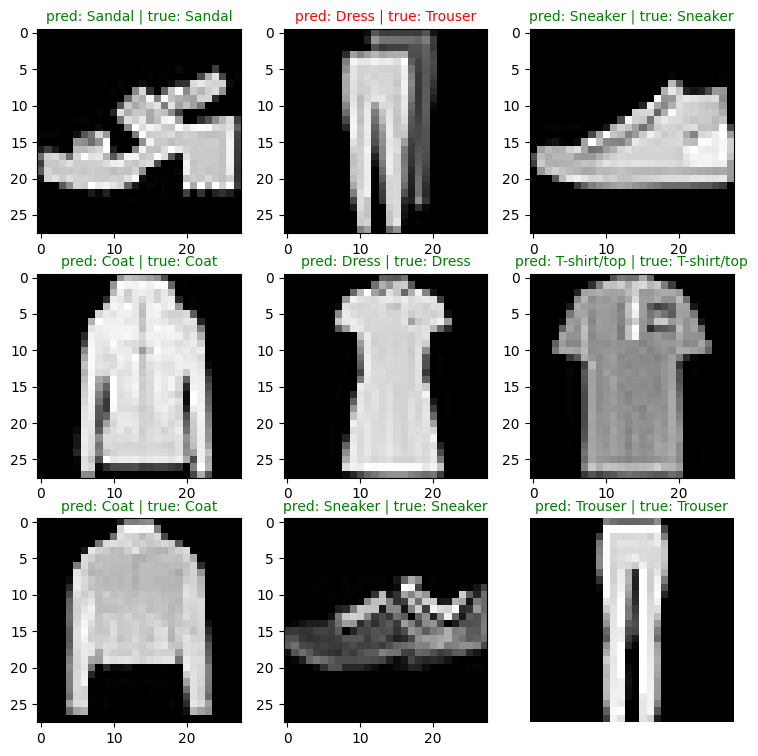

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,9))
nrows=3
ncols=3
for i, sample in enumerate(test_samples):
  plt.subplot(nrows,ncols,i+1)
  plt.imshow(sample.squeeze(),cmap="gray")
  title_text= f"pred: {class_name[pred_classes[i]]} | true: {class_name[test_labels[i]]}"
  plt.title(f"pred: {class_name[pred_classes[i]]} | true: {class_name[test_labels[i]]}")

  if pred_classes[i]==test_labels[i]:
    plt.title(title_text,fontsize=10,color="green")
  else:
    plt.title(title_text,fontsize=10,color="red")

plt.axis(False)

In [ ]:
import mlxtend

y_preds=[]
model_2.eval()
with torch.inference_mode():
  for x,y in tqdm(test_dataloader,desc="making predictions.."):
    x,y=x.to(device),y.to(device)
    y_logit=model_2(x)
    y_pred=torch.softmax(y_logit.squeeze(),dim=0).argmax(dim=1)
    y_preds.append(y_pred.cpu())



y_pred_tensor=torch.cat(y_preds)
y_pred_tensor

making predictions..:   0%|          | 0/313 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 0, 1, 8])

In [ ]:
try:
  import torchmetrics, mlxtend
  print(f"torchmetrics version:{torchmetrics.__version__}")
  print(f"mlxtend version:{mlxtend.__version__}")
except:
  !pip install torchmetrics mlxtend

torchmetrics version:1.9.0
mlxtend version:0.23.4


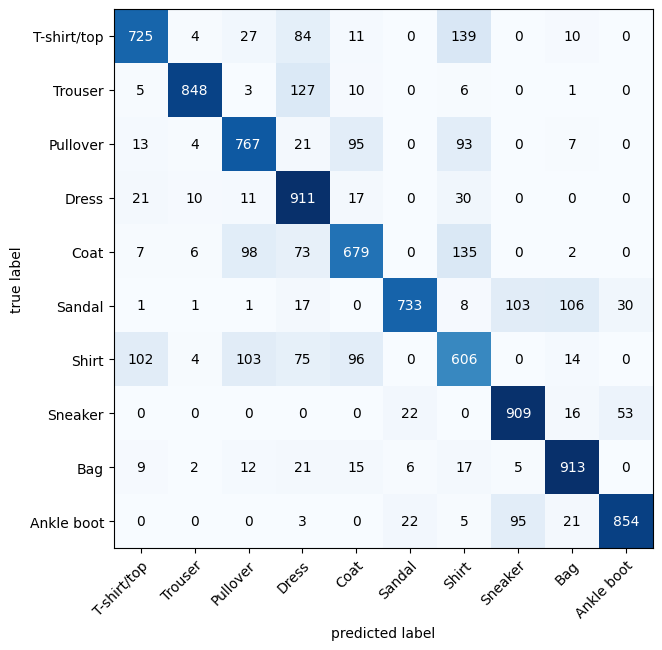

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat=ConfusionMatrix(num_classes=len(class_name),task="multiclass")
confmat_tensor=confmat(preds=y_pred_tensor,target=test_data.targets)


fig,ax=plot_confusion_matrix(conf_mat=confmat_tensor.numpy(),
                             figsize=(10,7),
                             class_names=class_name)

In [ ]:
!ls /content

data  drive  sample_data


In [77]:
import nbformat
from google.colab import drive
import glob

drive.mount('/content/drive')

notebooks = glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)

print(notebooks)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['/content/drive/MyDrive/Colab Notebooks/Untitled0.ipynb', '/content/drive/MyDrive/Colab Notebooks/base2.ipynb', '/content/drive/MyDrive/Colab Notebooks/transformplease.ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled1.ipynb', '/content/drive/MyDrive/Colab Notebooks/Untitled2.ipynb', '/content/drive/MyDrive/Colab Notebooks/deeplearning.ipynb', '/content/drive/MyDrive/Colab Notebooks/binaryandmulticlassifyication(Small).ipynb', '/content/drive/MyDrive/Colab Notebooks/base1.ipynb', '/content/drive/MyDrive/Colab Notebooks/breastcancer.ipynb', '/content/drive/MyDrive/Colab Notebooks/cvpytorch.ipynb', '/content/drive/MyDrive/Colab Notebooks/Copy of fashionmnistcnn.ipynb', '/content/drive/MyDrive/Colab Notebooks/fashionmnistcnn.ipynb', '/content/drive/MyDrive/Colab Notebooks/FashionMNISTCNN.ipynb', '/content/drive/MyDrive/Colab Notebooks/FashionMNISTCNN2.ip

In [78]:
import nbformat

path = "/content/drive/MyDrive/Colab Notebooks/FashionMNISTCNN2.ipynb"

with open(path, "r", encoding="utf-8") as f:
    nb = nbformat.read(f, as_version=4)

if "widgets" in nb["metadata"]:
    del nb["metadata"]["widgets"]

with open(path, "w", encoding="utf-8") as f:
    nbformat.write(nb, f)

print("Notebook fixed!")

Notebook fixed!
